In [1]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

# Dask will automatically submit SLURM jobs for you
cluster = SLURMCluster(
    cores=8,
    memory="128GB",
    processes=8,
    walltime="08:00:00",
    #qos="np",
    #account='spitfabi',
    #interface='ib0'  # or 'eth0', depends on your HPC
    job_extra_directives=[
        "--account=spitvent",
        "--qos=np"
        # "--constraint=haswell",
        # "--exclusive",
        # "--mail-type=END,FAIL",
        # "--mail-user=your.email@domain.com"
    ]
)

# Scale to desired number of workers
cluster.scale(jobs=1)  # This submits 1 SLURM job
# Connect client
client = Client(cluster)
#cluster.adapt(minimum_jobs=1, maximum_jobs=4)


In [2]:
import xarray as xr
import numpy as np
import pandas as pd

Reference file

In [3]:
path_forcing = '/ec/res4/hpcperm/itcv/ecearth4/amip_forcing/'
exp = 'pic7'
path = '/ec/res4/scratch/itcv/ece4/'+exp+'/output/nemo/'

In [4]:
ds_tos = xr.open_mfdataset(path_forcing + 'tosbcs_input*.nc')
ds_siconc = xr.open_mfdataset(path_forcing + 'siconcbcs_input*.nc')

/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 442.63 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


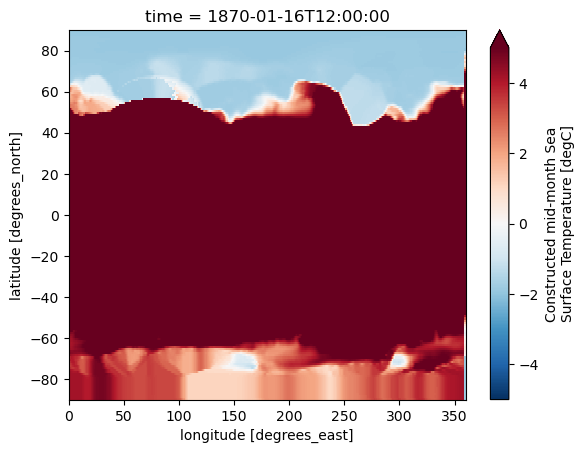

In [21]:
ds_tos.tosbcs[0].plot.pcolormesh(vmin=-5)

Compute climatology

In [5]:
ds_year = xr.open_mfdataset(path + '*_oce_1m_T_*.nc')

In [13]:
ds_year.tos

<xarray.DataArray 'tos' (time_counter: 3600, y: 148, x: 180)> Size: 384MB
dask.array<concatenate, shape=(3600, 148, 180), dtype=float32, chunksize=(1, 148, 180), chunktype=numpy.ndarray>
Coordinates:
    nav_lat        (y, x) float32 107kB dask.array<chunksize=(148, 180), meta=np.ndarray>
    nav_lon        (y, x) float32 107kB dask.array<chunksize=(148, 180), meta=np.ndarray>
    time_centered  (time_counter) datetime64[ns] 29kB dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter   (time_counter) datetime64[ns] 29kB 1850-01-16T12:00:00 ......
Dimensions without coordinates: y, x
Attributes:
    standard_name:       sea_surface_temperature
    long_name:           potential sea surface temperature
    units:               degC
    online_operation:    average
    interval_operation:  5400 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 5400 s)

In [ ]:
# from scipy import stats

# trend = np.zeros([148,180])
# for i in range(180):
#     for j in range(148):
#         trend[j,i] = stats.linregress(np.arange(0,300), ds_year.tos.groupby('time_counter.year').mean()[:,j,i])[0]

In [6]:
mean_tos = ds_year.tos.groupby('time_counter.month').mean()
mean_tos.to_netcdf(path_forcing +'/'+exp+'/'+ exp+'_oce_clim.nc')

In [7]:
ds_year = xr.open_mfdataset(path + '*_ice_1m_*.nc')

In [8]:
mean_siconc = ds_year.siconc.groupby('time_counter.month').mean().compute()

In [9]:
mean_siconc.to_netcdf(path_forcing +'/'+exp+'/'+ exp+'_siconc_clim.nc')

Check after remapping and filling \
cdo remapbil,r360x180 \
cdo setmisstoc,0

In [10]:
siconc = xr.open_mfdataset(path_forcing+'/'+exp+'/'+exp+'_siconc_clim_fr.nc')
#tos = xr.open_mfdataset(path_forcing+'ctl0_tos_clim_filled.nc')
tos = xr.open_mfdataset(path_forcing+'/'+exp+'/'+exp+'_oce_clim_fr.nc')


In [11]:
tos

<xarray.Dataset> Size: 3MB
Dimensions:  (lon: 360, lat: 180, month: 12)
Coordinates:
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * month    (month) float64 96B 1.0 2.0 3.0 4.0 5.0 ... 8.0 9.0 10.0 11.0 12.0
Data variables:
    tos      (month, lat, lon) float32 3MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Tue Feb 10 23:32:27 2026: cdo remapbil,r360x180 pic4_oce_cl...
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

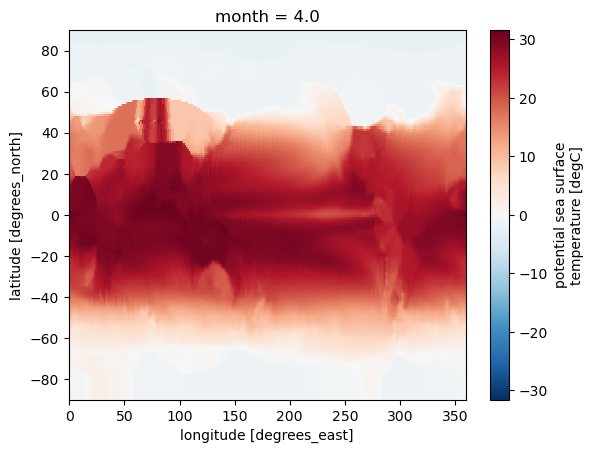

In [20]:
(tos.tos[3]).plot.pcolormesh()

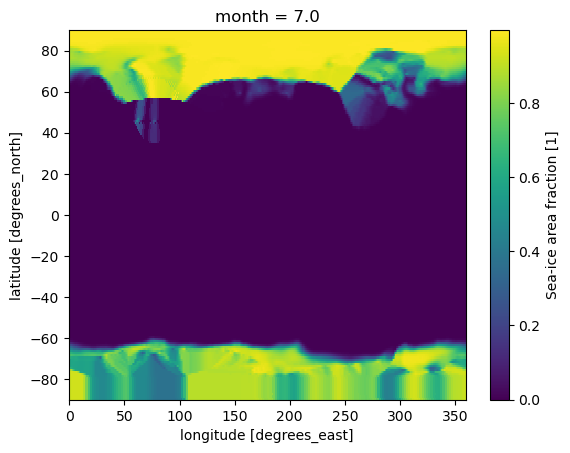

In [21]:
siconc.siconc[6].plot.pcolormesh()

Assign new values

In [11]:
siconcbcs = ds_siconc.siconcbcs
tosbcs = ds_tos.tosbcs

In [12]:
src_tos = tos.tos.interp_like(tosbcs[0])
src_siconc = siconc.siconc.interp_like(siconcbcs[0])

In [14]:
tosbcs[0]

<xarray.DataArray 'tosbcs' (lat: 180, lon: 360)> Size: 259kB
dask.array<getitem, shape=(180, 360), dtype=float32, chunksize=(180, 360), chunktype=numpy.ndarray>
Coordinates:
    time     datetime64[ns] 8B 1870-01-16T12:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      Constructed mid-month Sea Surface Temperature
    units:          degC
    cell_methods:   time: point
    cell_measures:  area: areacello

In [13]:
for j in range(147):
        
        #tosbcs[12*j:(j+1)*12,:,:] = src_tos.where(src_tos.notnull(), 0).values
        tosbcs[12*j:(j+1)*12,:,:] = src_tos.where(src_tos.notnull(), tosbcs[0]).values
        #siconcbcs[12*j:(j+1)*12,:,:] = src_siconc.where(src_siconc.notnull(), 0).values*100
        siconcbcs[12*j:(j+1)*12,:,:] = src_siconc.where(src_siconc.notnull(), siconcbcs[0]/100).values*100

#siconcbcs[-6:,:,:] = src_siconc[:6].where(src_siconc[:6].notnull(), siconcbcs[0]/100).values*100
#tosbcs[-6:,:,:] = src_tos[:6].where(src_tos[:6].notnull(), tosbcs[0]).values

/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.06 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 12.06 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 15.07 MiB.
This ma

In [ ]:
for j in range(147):
    for i in range(12):
        tosbcs[i+12*j,:,:] = src_tos[i].where(src_tos[i].notnull(), tosbcs[i]).values
        #siconcbcs[12*j:(j+1)*12,:,:] = src_siconc.where(src_siconc.notnull(), 0).values*100
        siconcbcs[12*j+i,:,:] = src_siconc[i].where(src_siconc[i].notnull(), siconcbcs[i]/100).values*100

#siconcbcs[-6:,:,:] = src_siconc[:6].where(src_siconc[:6].notnull(), siconcbcs[0]/100).values*100
#tosbcs[-6:,:,:] = src_tos[:6].where(src_tos[:6].notnull(), tosbcs[0]).values

/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 442.90 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


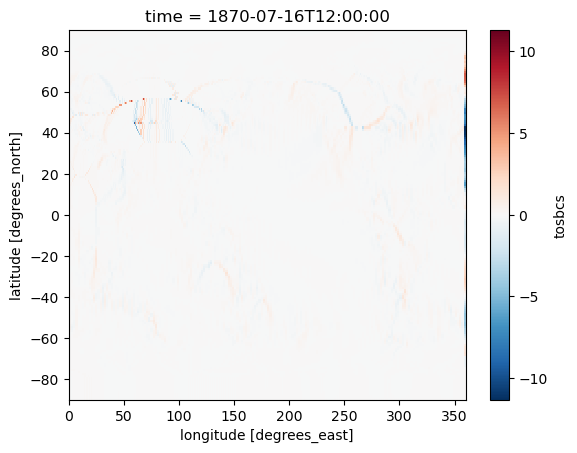

In [14]:
(tosbcs[6]-tos.tos[6].values).plot.pcolormesh()

/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 186.94 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


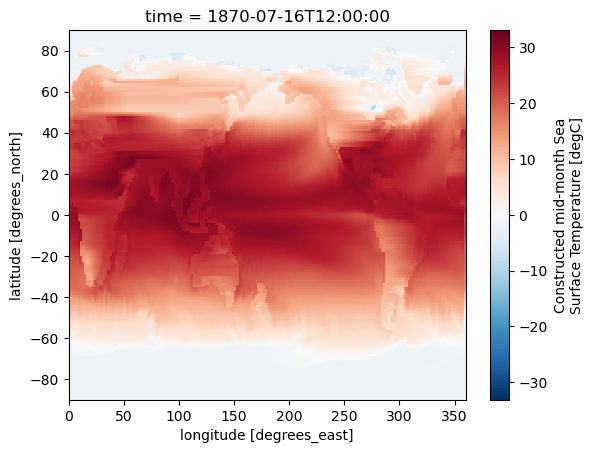

In [19]:
tosbcs[6].plot.pcolormesh()

In [14]:
siconcbcs.to_netcdf(path_forcing +'/'+exp+'/'+ 'siconcbcs_'+exp+'_fr.nc', 'w')
tosbcs.to_netcdf(path_forcing +'/'+exp+'/'+ 'tosbcs_'+exp+'_fr.nc', 'w')

/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 442.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 442.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 442.65 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


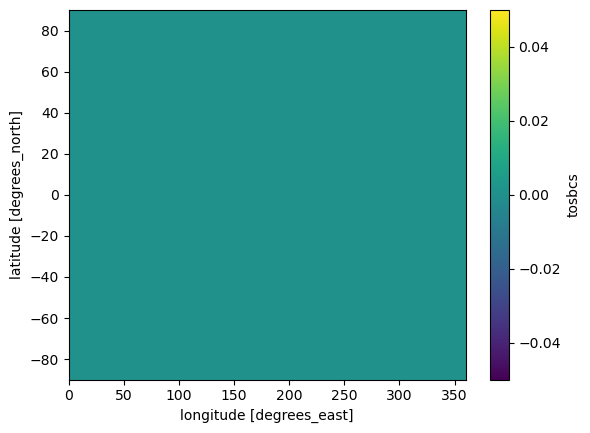

In [27]:
(tosbcs[6]- tosbcs[1206]).plot.pcolormesh()

In [ ]:
# # 1. Select first 20 years (240 months)
# ds_ref = ds.isel(time=slice(0, 240))

# # 2. Shift time back by 20 calendar years (preserves day & hour)
# new_time = pd.DatetimeIndex(ds_ref.time.values) - pd.DateOffset(years=20)
# ds_ref = ds_ref.assign_coords(time=new_time)

# # 3. Concatenate replicated data with original dataset
# ds_extended = xr.concat([ds_ref, ds], dim="time").sortby("time")

/perm/itcv/Miniforge3/envs/ece4/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 187.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


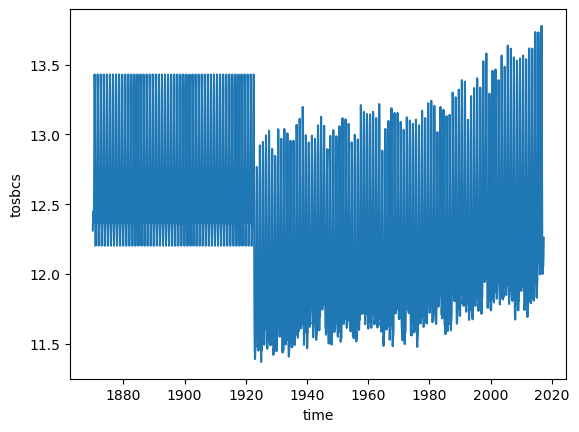

In [21]:
(tosbcs[:-1].mean(axis=(1,2))).plot()